# BiLSTM + Word Embedding trên bộ dữ liệu ViHSD
> **Môi trường:** Kaggle Notebook — GPU P100  
> **Task:** Vietnamese Hate Speech Detection (3 nhãn: CLEAN · OFFENSIVE · HATE)

---
## Pipeline tổng quan
```
Raw text → Tokenize (underthesea) → Word Embedding (PhoBERT static / fastText vi)
        → BiLSTM → Dropout → Dense → Softmax (3 classes)
```

## 1. Cài đặt thư viện

In [102]:
# Kaggle đã có sẵn torch, sklearn — chỉ cần thêm underthesea & datasets
!pip install underthesea datasets -q

In [103]:
import torch
print(f'PyTorch hiện tại : {torch.__version__}')
print(f'CUDA available   : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU              : {torch.cuda.get_device_name(0)}')

PyTorch hiện tại : 2.10.0+cu128
CUDA available   : True
GPU              : Tesla T4


## 2. Import & kiểm tra GPU

In [104]:
import os, re, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

from sklearn.metrics import classification_report, confusion_matrix, f1_score
from datasets import load_dataset

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 3. Tải bộ dữ liệu ViHSD

In [105]:
train_df = pd.read_csv ('/content/train.csv')
val_df   = pd.read_csv ('/content/dev.csv')
test_df  = pd.read_csv ('/content/test.csv')

# Xem cấu trúc
print('\n--- Mẫu dữ liệu ---')
print(train_df.head(5))
print(f'\nTrain: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}')


--- Mẫu dữ liệu ---
                                           free_text  label_id
0  Em được làm fan cứng luôn rồi nè ❤️ reaction q...         0
1  Đúng là bọn mắt híp lò xo thụt :))) bên việt n...         2
2           Đậu Văn Cường giờ giống thằng sida hơn à         0
3  CÔN ĐỒ CỤC SÚC VÔ NHÂN TÍNH ĐỀ NGHI VN. NHÀ NƯ...         2
4  Từ lý thuyết đến thực hành là cả 1 câu chuyện ...         0

Train: 24,048  |  Val: 2,672  |  Test: 6,680


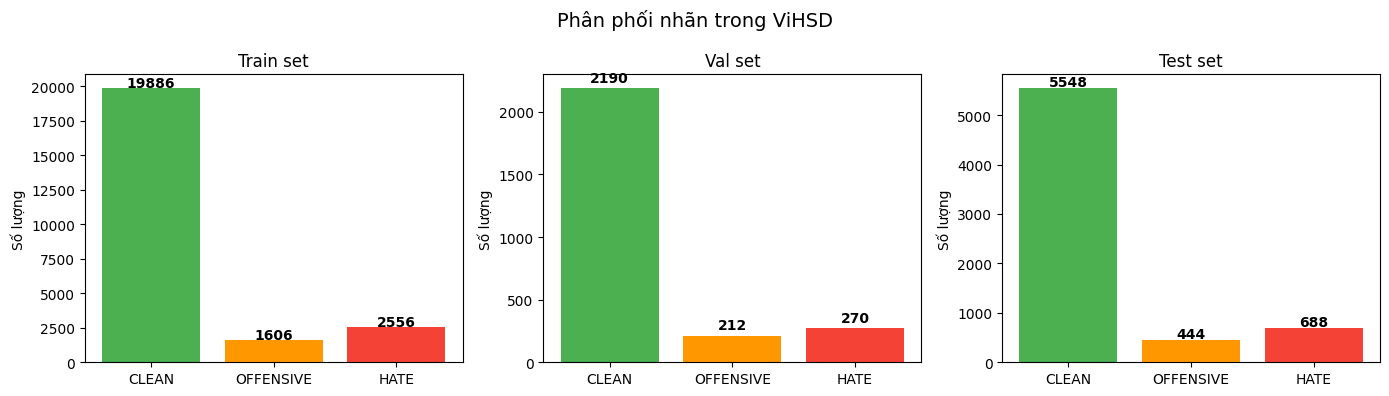

In [106]:
# Phân phối nhãn
LABEL_MAP = {0: 'CLEAN', 1: 'OFFENSIVE', 2: 'HATE'}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (split_name, df) in zip(axes, [('Train', train_df), ('Val', val_df), ('Test', test_df)]):
    counts = df['label_id'].value_counts().sort_index()
    ax.bar([LABEL_MAP[i] for i in counts.index], counts.values,
           color=['#4CAF50', '#FF9800', '#F44336'])
    ax.set_title(f'{split_name} set')
    ax.set_ylabel('Số lượng')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.suptitle('Phân phối nhãn trong ViHSD', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Tiền xử lý văn bản

In [107]:
from underthesea import word_tokenize

def clean_text(text: str) -> str:
    """Làm sạch cơ bản cho tiếng Việt."""
    text = str(text).lower().strip()
    # Xóa URL
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Xóa mention, hashtag
    text = re.sub(r'@\w+|#\w+', '', text)
    # Xóa ký tự đặc biệt, giữ lại chữ và số Việt
    text = re.sub(r'[^\w\s\u00C0-\u024F\u1E00-\u1EFF]', ' ', text)
    # Chuẩn hóa khoảng trắng
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize_vi(text: str) -> list:
    """Word-level tokenize tiếng Việt bằng underthesea."""
    cleaned = clean_text(text)
    tokens = word_tokenize(cleaned, format='text').split()
    # Ensure that an empty list of tokens does not cause an error.
    # Replace with UNK_TOKEN if tokens list is empty.
    if not tokens:
        return [UNK_TOKEN]
    return tokens

# Test thử
sample = "Mày là đồ ngu! Xem tại https://example.com #hate @user123"
print('Input :', sample)
print('Tokens:', tokenize_vi(sample))

Input : Mày là đồ ngu! Xem tại https://example.com #hate @user123
Tokens: ['mày', 'là', 'đồ', 'ngu', 'xem', 'tại']


In [90]:
%%time
# Tokenize toàn bộ dataset (mất ~3-5 phút trên P100 CPU side)
print('Tokenizing train...')
train_df['tokens'] = train_df['free_text'].apply(tokenize_vi)
print('Tokenizing val...')
val_df['tokens']   = val_df['free_text'].apply(tokenize_vi)
print('Tokenizing test...')
test_df['tokens']  = test_df['free_text'].apply(tokenize_vi)
print('Done!')

# Thống kê độ dài
all_lens = train_df['tokens'].apply(len)
print(f'\nĐộ dài câu — mean: {all_lens.mean():.1f} | max: {all_lens.max()} | 95th: {np.percentile(all_lens, 95):.0f}')

Tokenizing train...
Tokenizing val...
Tokenizing test...
Done!

Độ dài câu — mean: 9.7 | max: 1191 | 95th: 27
CPU times: user 27.1 s, sys: 89.4 ms, total: 27.2 s
Wall time: 39.8 s


## 5. Xây dựng Vocabulary & Embedding

In [ ]:
# ── Hyperparameters ──────────────────────────────────────────────
MAX_VOCAB    = 15_000   # kích thước từ điển tối đa
MAX_LEN      = 64      # độ dài tối đa của câu (padding/truncation)
EMBED_DIM    = 300      # số chiều embedding
HIDDEN_DIM   = 64      # số chiều hidden state BiLSTM
NUM_LAYERS   = 1        # số lớp BiLSTM
DROPOUT      = 0.6
BATCH_SIZE   = 256
NUM_EPOCHS   = 8
LR           = 5e-4
NUM_CLASSES  = 3
PAD_TOKEN    = '<PAD>'
UNK_TOKEN    = '<UNK>'

freeze_embed = False   # để True nếu muốn giữ cố định embedding
# ─────────────────────────────────────────────────────────────────

class Vocabulary:
    def __init__(self, max_size=MAX_VOCAB):
        self.max_size = max_size
        self.word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
        self.idx2word = {0: PAD_TOKEN, 1: UNK_TOKEN}

    def build(self, token_lists):
        counter = Counter(tok for tokens in token_lists for tok in tokens)
        for word, _ in counter.most_common(self.max_size - 2):
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx]  = word
        print(f'Vocabulary size: {len(self.word2idx):,}')

    def encode(self, tokens, max_len=MAX_LEN):
        ids = [self.word2idx.get(t, 1) for t in tokens[:max_len]]
        # padding
        ids += [0] * (max_len - len(ids))
        return ids

vocab = Vocabulary()
vocab.build(train_df['tokens'])

Vocabulary size: 14,999


In [92]:
# Khởi tạo embedding ngẫu nhiên (trainable)
import gzip, shutil, os
import numpy as np

def load_pretrained_embeddings(vocab, embed_dim, vec_path="/content/cc.vi.300.vec"):

    # Tự động giải nén nếu chưa có file .vec
    gz_path = vec_path + ".gz"
    if not os.path.exists(vec_path) and os.path.exists(gz_path):
        print("Đang giải nén...")
        with gzip.open(gz_path, 'rb') as f_in, open(vec_path, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
        print("Giải nén xong!")

    print("Đang load fastText vectors (mất 2–4 phút)...")
    ft = {}
    with open(vec_path, 'r', encoding='utf-8') as f:
        header = f.readline()  # dòng đầu: "số_từ số_chiều"
        total, dim = map(int, header.strip().split())
        print(f"File chứa {total:,} từ, {dim} chiều")
        for i, line in enumerate(f):
            parts = line.rstrip().split(' ')
            word  = parts[0]
            if word in vocab.word2idx:  # chỉ load từ có trong vocab → tiết kiệm RAM
                ft[word] = np.array(parts[1:], dtype=np.float32)
            if (i+1) % 500_000 == 0:
                print(f"  Đã đọc {i+1:,} / {total:,} dòng...")

    V = len(vocab.word2idx)
    matrix = np.zeros((V, embed_dim), dtype=np.float32)

    found, not_found = 0, 0
    for word, idx in vocab.word2idx.items():
        if word in ft:
            matrix[idx] = ft[word]
            found += 1
        else:
            matrix[idx] = np.random.uniform(-0.1, 0.1, embed_dim)
            not_found += 1

    matrix[0] = 0  # <PAD> = zero vector
    print(f"Embedding matrix : {matrix.shape}")
    print(f"Tìm thấy         : {found:,} / {V:,} từ ({found/V*100:.1f}%)")
    print(f"Không tìm thấy   : {not_found:,} từ → random init")
    return matrix

embedding_matrix = load_pretrained_embeddings(vocab, EMBED_DIM)

Đang load fastText vectors (mất 2–4 phút)...
File chứa 2,000,000 từ, 300 chiều
  Đã đọc 500,000 / 2,000,000 dòng...
  Đã đọc 1,000,000 / 2,000,000 dòng...
  Đã đọc 1,500,000 / 2,000,000 dòng...
  Đã đọc 2,000,000 / 2,000,000 dòng...
Embedding matrix : (14999, 300)
Tìm thấy         : 5,782 / 14,999 từ (38.5%)
Không tìm thấy   : 9,217 từ → random init


## 6. Dataset & DataLoader

In [93]:
class ViHSDDataset(Dataset):
    def __init__(self, df, vocab, max_len=MAX_LEN):
        self.inputs  = [vocab.encode(toks, max_len) for toks in df['tokens']]
        self.lengths = [max(1, min(len(toks), max_len)) for toks in df['tokens']]  # ← thêm max(1, ...)
        self.labels  = df['label_id'].tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.inputs[idx],  dtype=torch.long),
            torch.tensor(self.lengths[idx], dtype=torch.long),
            torch.tensor(self.labels[idx],  dtype=torch.long)
        )

train_dataset = ViHSDDataset(train_df, vocab)
val_dataset   = ViHSDDataset(val_df,   vocab)
test_dataset  = ViHSDDataset(test_df,  vocab)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Batches — Train: 94 | Val: 11 | Test: 27


## 7. Mô hình BiLSTM

In [94]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers,
                 num_classes, dropout, embedding_matrix=None, freeze_embed=False):
        super().__init__()

        # ── Embedding Layer ──────────────────────────────────────
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if embedding_matrix is not None:
            self.embedding.weight = nn.Parameter(
                torch.tensor(embedding_matrix, dtype=torch.float32)
            )
            if freeze_embed:
                self.embedding.weight.requires_grad = False

        self.embed_dropout = nn.Dropout(dropout)

        # ── BiLSTM ───────────────────────────────────────────────
        self.bilstm = nn.LSTM(
            input_size    = embed_dim,
            hidden_size   = hidden_dim,
            num_layers    = num_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = dropout if num_layers > 1 else 0
        )

        # ── Attention (optional, đơn giản) ───────────────────────
        self.attention = nn.Linear(hidden_dim * 2, 1)

        # ── Classifier head ──────────────────────────────────────
        self.dropout    = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_dim * 2)
        self.fc1        = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc2        = nn.Linear(hidden_dim, num_classes)
        self.relu       = nn.ReLU()

    def attention_pooling(self, lstm_out, lengths):
        """Additive attention pooling qua các time steps."""
        # lstm_out: (B, T, 2H)
        scores = self.attention(lstm_out).squeeze(-1)          # (B, T)
        # Mask padding positions
        mask = torch.arange(lstm_out.size(1), device=lstm_out.device)
        mask = mask.unsqueeze(0) >= lengths.unsqueeze(1)       # True = pad
        scores = scores.masked_fill(mask, float('-inf'))
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)   # (B, T, 1)
        context = (lstm_out * weights).sum(dim=1)              # (B, 2H)
        return context

    def forward(self, x, lengths):
        # x: (B, T)
        emb = self.embed_dropout(self.embedding(x))            # (B, T, E)

        # Pack sequence để bỏ qua padding khi tính LSTM
        packed = pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        lstm_out, _ = self.bilstm(packed)                      # packed output
        lstm_out, _ = pad_packed_sequence(lstm_out, batch_first=True,
                                          total_length=x.size(1))  # (B, T, 2H)

        # Attention pooling
        context = self.attention_pooling(lstm_out, lengths)    # (B, 2H)
        context = self.layer_norm(context)

        # Classifier
        out = self.dropout(self.relu(self.fc1(context)))       # (B, H)
        logits = self.fc2(out)                                 # (B, C)
        return logits

model = BiLSTMClassifier(
    vocab_size       = len(vocab.word2idx),
    embed_dim        = EMBED_DIM,
    hidden_dim       = HIDDEN_DIM,
    num_layers       = NUM_LAYERS,
    num_classes      = NUM_CLASSES,
    dropout          = DROPOUT,
    embedding_matrix = embedding_matrix,
    freeze_embed     = False   # thử True trước nếu vẫn overfit
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTổng tham số có thể học: {total_params:,}')

BiLSTMClassifier(
  (embedding): Embedding(14999, 300, padding_idx=0)
  (embed_dropout): Dropout(p=0.6, inplace=False)
  (bilstm): LSTM(300, 64, batch_first=True, bidirectional=True)
  (attention): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.6, inplace=False)
  (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=3, bias=True)
  (relu): ReLU()
)

Tổng tham số có thể học: 4,695,928


## 8. Loss, Optimizer & Scheduler

In [95]:
# Class weights để xử lý mất cân bằng nhãn
label_counts = train_df['label_id'].value_counts().sort_index().values
class_weights = torch.tensor(
    len(train_df) / (NUM_CLASSES * label_counts), dtype=torch.float32
).to(DEVICE)
print('Class weights:', class_weights.cpu().numpy().round(3))

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
)

Class weights: [0.403 4.991 3.136]


## 9. Vòng lặp Training

In [96]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0
    for x, lengths, y in loader:
        x, lengths, y = x.to(DEVICE), lengths.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x, lengths)
        loss   = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss    += loss.item() * y.size(0)
        total_correct += (logits.argmax(1) == y).sum().item()
        total_samples += y.size(0)
    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_samples = 0, 0, 0
    all_preds, all_labels = [], []
    for x, lengths, y in loader:
        x, lengths, y = x.to(DEVICE), lengths.to(DEVICE), y.to(DEVICE)
        logits = model(x, lengths)
        loss   = criterion(logits, y)
        preds  = logits.argmax(1)
        total_loss    += loss.item() * y.size(0)
        total_correct += (preds == y).sum().item()
        total_samples += y.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / total_samples, total_correct / total_samples, macro_f1


# ── Training loop ────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
best_f1, best_epoch = 0, 0

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'Val F1':>6} | {'Time':>6}")
print('-' * 72)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc, vl_f1 = evaluate(model, val_loader, criterion)
    elapsed = time.time() - t0

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['val_f1'].append(vl_f1)

    scheduler.step(vl_f1)

    flag = ''
    if vl_f1 > best_f1:
        best_f1, best_epoch = vl_f1, epoch
        torch.save(model.state_dict(), 'best_bilstm_vihsd.pt')
        flag = ' ✓ saved'

    print(f'{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>9.4f} | {vl_loss:>8.4f} | {vl_acc:>7.4f} | {vl_f1:>6.4f} | {elapsed:>5.1f}s{flag}')

print(f'\nBest Val F1 = {best_f1:.4f} tại epoch {best_epoch}')

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val F1 |   Time
------------------------------------------------------------------------
     1 |     1.0537 |    0.4404 |   0.9304 |  0.6213 | 0.4723 |   4.2s ✓ saved
     2 |     0.8873 |    0.6644 |   0.7961 |  0.7017 | 0.5299 |   3.4s ✓ saved
     3 |     0.7549 |    0.7332 |   0.7652 |  0.7680 | 0.5855 |   2.6s ✓ saved
     4 |     0.6634 |    0.7737 |   0.7849 |  0.7343 | 0.5620 |   2.7s
     5 |     0.5860 |    0.7997 |   0.8023 |  0.7751 | 0.5956 |   2.9s ✓ saved
     6 |     0.5225 |    0.8217 |   0.8190 |  0.7530 | 0.5884 |   4.2s
     7 |     0.4815 |    0.8375 |   0.9341 |  0.7878 | 0.6016 |   3.5s ✓ saved
     8 |     0.4221 |    0.8568 |   0.9792 |  0.7878 | 0.6009 |   2.6s
     9 |     0.3833 |    0.8653 |   1.1201 |  0.7960 | 0.5980 |   2.6s
    10 |     0.3546 |    0.8744 |   1.0930 |  0.7661 | 0.5807 |   2.6s

Best Val F1 = 0.6016 tại epoch 7


## 10. Visualize quá trình training

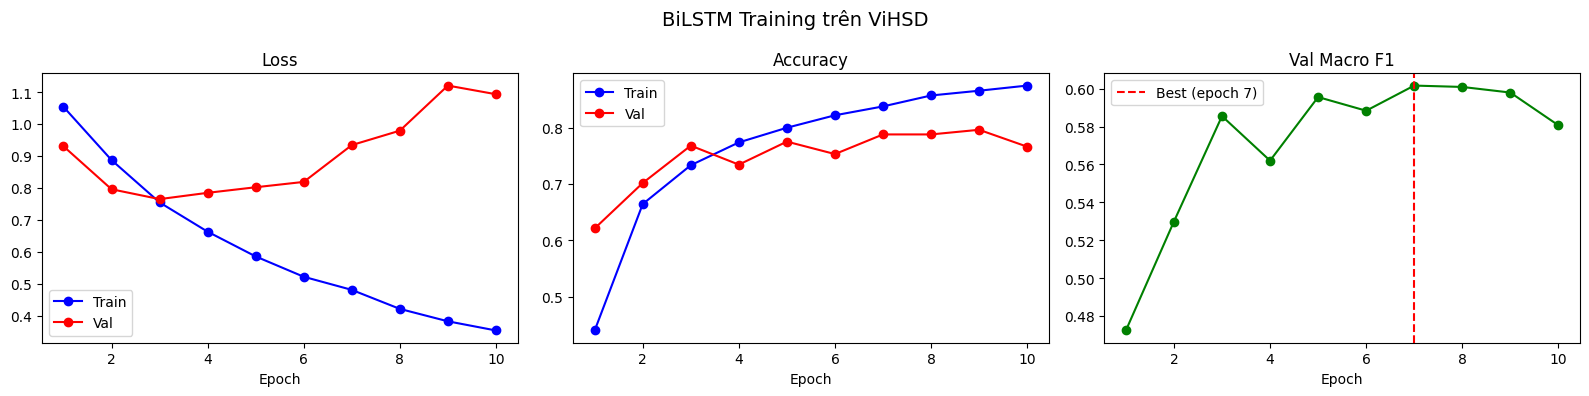

In [97]:
epochs_range = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train')
axes[0].plot(epochs_range, history['val_loss'],   'r-o', label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Train')
axes[1].plot(epochs_range, history['val_acc'],   'r-o', label='Val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')

axes[2].plot(epochs_range, history['val_f1'], 'g-o')
axes[2].axvline(best_epoch, color='red', linestyle='--', label=f'Best (epoch {best_epoch})')
axes[2].set_title('Val Macro F1'); axes[2].legend(); axes[2].set_xlabel('Epoch')

plt.suptitle('BiLSTM Training trên ViHSD', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## 11. Đánh giá trên tập Test

In [98]:
# Load best model
model.load_state_dict(torch.load('best_bilstm_vihsd.pt', map_location=DEVICE))

@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for x, lengths, y in loader:
        x, lengths = x.to(DEVICE), lengths.to(DEVICE)
        logits = model(x, lengths)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(y.numpy())
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = get_predictions(model, test_loader)

print('='*60)
print('Classification Report trên Test Set')
print('='*60)
print(classification_report(
    y_true, y_pred,
    target_names=['CLEAN', 'OFFENSIVE', 'HATE'],
    digits=4
))

Classification Report trên Test Set
              precision    recall  f1-score   support

       CLEAN     0.9515    0.8425    0.8937      5548
   OFFENSIVE     0.2993    0.5676    0.3919       444
        HATE     0.4806    0.6468    0.5514       688

    accuracy                         0.8040      6680
   macro avg     0.5771    0.6856    0.6123      6680
weighted avg     0.8597    0.8040    0.8251      6680



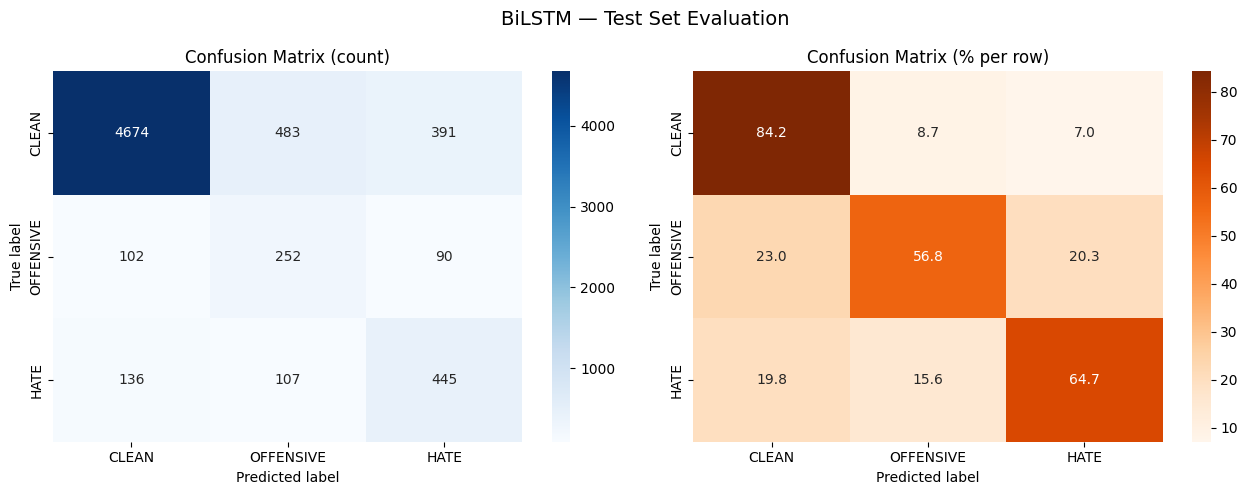

In [99]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labels = ['CLEAN', 'OFFENSIVE', 'HATE']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=labels, yticklabels=labels)
axes[0].set_title('Confusion Matrix (count)')
axes[0].set_ylabel('True label'); axes[0].set_xlabel('Predicted label')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Oranges', ax=axes[1],
            xticklabels=labels, yticklabels=labels)
axes[1].set_title('Confusion Matrix (% per row)')
axes[1].set_ylabel('True label'); axes[1].set_xlabel('Predicted label')

plt.suptitle('BiLSTM — Test Set Evaluation', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## 12. Inference — Dự đoán câu mới

In [100]:
@torch.no_grad()
def predict(texts: list, model=model, vocab=vocab) -> list:
    model.eval()
    results = []
    for text in texts:
        tokens  = tokenize_vi(text)
        ids     = vocab.encode(tokens, MAX_LEN)
        length  = min(len(tokens), MAX_LEN)
        x       = torch.tensor([ids], dtype=torch.long).to(DEVICE)
        length_t = torch.tensor([length], dtype=torch.long).to(DEVICE)
        logits  = model(x, length_t)
        probs   = torch.softmax(logits, dim=-1).squeeze().cpu().numpy()
        label_id = probs.argmax()
        results.append({
            'text'      : text,
            'prediction': LABEL_MAP[label_id],
            'probs'     : {LABEL_MAP[i]: round(float(p), 4) for i, p in enumerate(probs)}
        })
    return results


# ── Demo ─────────────────────────────────────────────────────────
demo_texts = [
    "Hôm nay trời đẹp quá, đi chơi thôi!",
    "Mày ngu vãi, làm cái gì cũng hỏng hết!",
    "Tụi nó toàn là rác rưởi của xã hội, cần phải loại bỏ!",
    "Bộ phim hay lắm, mình xem đi xem lại mấy lần rồi.",
    "Đồ súc vật, mày không xứng đáng sống trên đời này!",
]

preds = predict(demo_texts)
print(f"{'Text':<55} | {'Nhãn':^12} | Xác suất")
print('-' * 100)
for r in preds:
    short = r['text'][:52] + '...' if len(r['text']) > 52 else r['text']
    prob_str = '  '.join([f"{k}: {v:.3f}" for k, v in r['probs'].items()])
    print(f"{short:<55} | {r['prediction']:^12} | {prob_str}")

Text                                                    |     Nhãn     | Xác suất
----------------------------------------------------------------------------------------------------
Hôm nay trời đẹp quá, đi chơi thôi!                     |    CLEAN     | CLEAN: 0.990  OFFENSIVE: 0.010  HATE: 0.001
Mày ngu vãi, làm cái gì cũng hỏng hết!                  |     HATE     | CLEAN: 0.129  OFFENSIVE: 0.424  HATE: 0.447
Tụi nó toàn là rác rưởi của xã hội, cần phải loại bỏ... |     HATE     | CLEAN: 0.059  OFFENSIVE: 0.151  HATE: 0.790
Bộ phim hay lắm, mình xem đi xem lại mấy lần rồi.       |    CLEAN     | CLEAN: 0.998  OFFENSIVE: 0.002  HATE: 0.000
Đồ súc vật, mày không xứng đáng sống trên đời này!      |     HATE     | CLEAN: 0.020  OFFENSIVE: 0.050  HATE: 0.930


## 13. Lưu model & vocab

In [101]:
import pickle, json

# Lưu vocabulary
with open('vocab_vihsd.pkl', 'wb') as f:
    pickle.dump(vocab, f)

# Lưu config
config = {
    'MAX_VOCAB': MAX_VOCAB, 'MAX_LEN': MAX_LEN, 'EMBED_DIM': EMBED_DIM,
    'HIDDEN_DIM': HIDDEN_DIM, 'NUM_LAYERS': NUM_LAYERS, 'DROPOUT': DROPOUT,
    'NUM_CLASSES': NUM_CLASSES, 'LABEL_MAP': LABEL_MAP, 'best_epoch': best_epoch,
    'best_val_f1': best_f1
}
with open('model_config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print('Đã lưu:')
print(' - best_bilstm_vihsd.pt   (model weights)')
print(' - vocab_vihsd.pkl        (vocabulary)')
print(' - model_config.json      (hyperparameters)')

Đã lưu:
 - best_bilstm_vihsd.pt   (model weights)
 - vocab_vihsd.pkl        (vocabulary)
 - model_config.json      (hyperparameters)
